# Impact of Discount Strategies on User Ordering Behavior

This project analyzes how different discount strategies influence user engagement and profitability in a food delivery platform.

## Problem Statement

Food delivery platforms frequently use discounts to drive user engagement.

This project aims to evaluate:
- Whether discounts significantly impact user ordering behavior  
- Which discount level provides the best balance between engagement and profitability  

## Dataset Description

The dataset is simulated to reflect realistic user behavior.

It consists of 3 groups:

- **Group A** → No discount  
- **Group B** → 20% discount  
- **Group C** → 60% discount  

### Columns

- User_ID  
- Group  
- Orders  
- Order_Value  

In [2]:
import pandas as pd
from scipy.stats import f_oneway
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
filepath=r"C:\Users\user\Downloads\userdataswiggy.xlsx"

In [4]:
df = pd.read_excel(filepath)

In [5]:
df.head()

,"User_ID,Group,Orders,Order_Value"
0,"1,A,1,220"
1,"2,A,0,180"
2,"3,A,1,250"
3,"4,A,2,300"
4,"5,A,1,210"


In [6]:
df = df[df.columns[0]].str.split(',', expand=True)

# Assign proper column names
df.columns = ['User_ID', 'Group', 'Orders', 'Order_Value']

print(df.head())

  User_ID Group Orders Order_Value
0       1     A      1         220
1       2     A      0         180
2       3     A      1         250
3       4     A      2         300
4       5     A      1         210


In [7]:
df['Orders'] = pd.to_numeric(df['Orders'], errors='coerce')
df['Order_Value'] = pd.to_numeric(df['Order_Value'], errors='coerce')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   User_ID      60 non-null     object 
 1   Group        60 non-null     object 
 2   Orders       60 non-null     float64
 3   Order_Value  60 non-null     float64
dtypes: float64(2), object(2)
memory usage: 2.1+ KB


In [9]:
df.groupby('Group')['Orders'].mean()
df.groupby('Group')['Order_Value'].mean()


Group
A    243.5
B    416.5
C    651.0
Name: Order_Value, dtype: float64

### Observations:
- Orders increase with discount levels
- Higher discounts show higher average order value

In [10]:
df = df.dropna()

In [11]:
group_A = df[df['Group']=='A']['Orders']
group_B = df[df['Group']=='B']['Orders']
group_C = df[df['Group']=='C']['Orders']
f_stat, p_value = f_oneway(group_A, group_B, group_C)

In [12]:
print("F-stat:", f_stat)
print("P-value:", p_value)


F-stat: 47.5
P-value: 7.242543798622683e-13


### Observations:
- Orders increase with discount levels
- Higher discounts show higher average order value

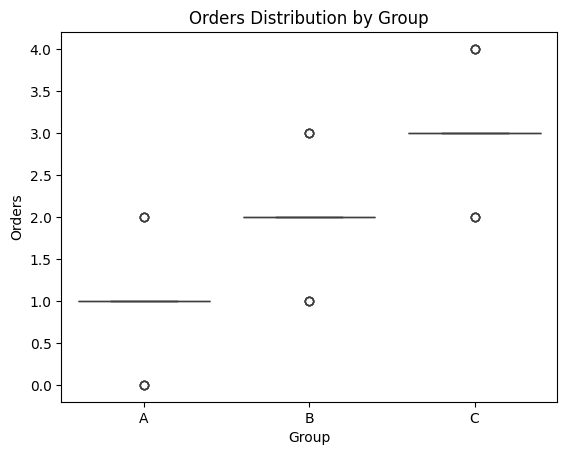

In [13]:
sns.boxplot(x='Group', y='Orders', data=df)
plt.title("Orders Distribution by Group")
plt.show()

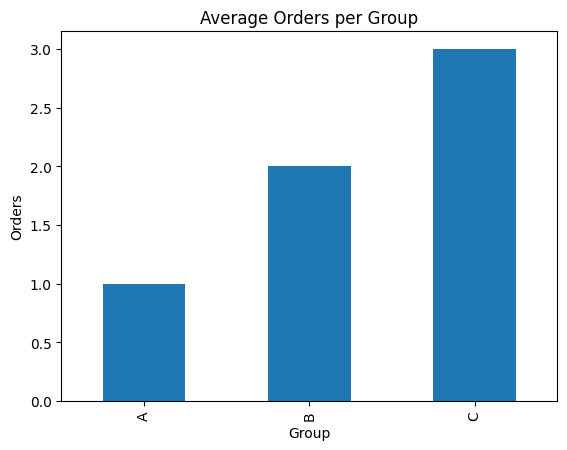

In [14]:
df.groupby('Group')['Orders'].mean().plot(kind='bar')
plt.title("Average Orders per Group")
plt.ylabel("Orders")
plt.show()

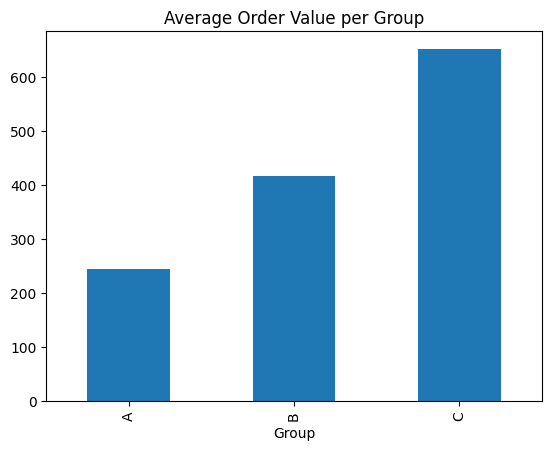

In [15]:
df.groupby('Group')['Order_Value'].mean().plot(kind='bar')
plt.title("Average Order Value per Group")
plt.show()

In [25]:
df['Discount'] = df['Group'].map({
    'A': 0.0,
    'B': 0.2,
    'C': 0.6
})

df['Discount_Amount'] = df['Order_Value'] * df['Discount']

df['Profit'] = df['Order_Value'] - df['Discount_Amount']

In [26]:
print(df.columns)

Index(['User_ID', 'Group', 'Orders', 'Order_Value', 'Discount',
       'Discount_Amount', 'Profit'],
      dtype='object')


In [27]:
roi_summary = df.groupby('Group').agg({
    'Orders': 'mean',
    'Order_Value': 'mean',
    'Profit': 'mean'
})

print(roi_summary)

       Orders  Order_Value  Profit
Group                             
A         1.0        243.5   243.5
B         2.0        416.5   333.2
C         3.0        651.0   260.4


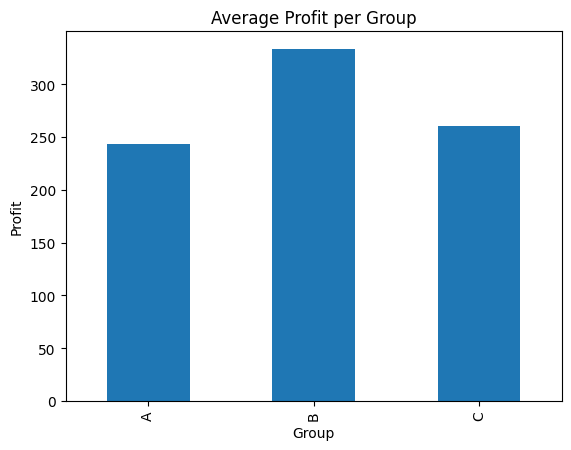

In [28]:
roi_summary['Profit'].plot(kind='bar')
plt.title("Average Profit per Group")
plt.ylabel("Profit")
plt.show()

## ROI Insights

- While higher discounts increase order volume, they also reduce profit margins
- Group B (20% discount) shows a strong balance between increased engagement and sustainable profit
- Group C (60% discount) drives the highest order value, but may not be the most profitable strategy
## Conclusion

This analysis shows that discount strategies significantly influence user behaviour. 

While higher discounts lead to increased engagement, moderate discounts provide a better balance between growth and profitability.

## Recommendation:
A 20% discount strategy is optimal for maintaining user engagement while ensuring sustainable revenue.